<a href="https://colab.research.google.com/github/Thakshi20010921/-recipe-hub/blob/main/Research_Final_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import torch
import platform

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Architecture:", platform.machine())
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA: 12.8
Architecture: x86_64
CUDA available: True
GPU: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls -lh /content/drive/MyDrive/Research_Project/Colab_Compiled_Wheels/

total 435M
-rw------- 1 root root 164M Jun 19 18:06 causal_conv1d-1.6.2.post1-cp312-cp312-linux_x86_64.whl
drwx------ 2 root root 4.0K Jun 19 18:06 da
drwx------ 2 root root 4.0K Jun 19 18:06 ea
-rw------- 1 root root 272M Jun 19 18:06 mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl


In [ ]:
!pip install --no-deps \
"/content/drive/MyDrive/Research_Project/Colab_Compiled_Wheels/causal_conv1d-1.6.2.post1-cp312-cp312-linux_x86_64.whl"

!pip install --no-deps \
"/content/drive/MyDrive/Research_Project/Colab_Compiled_Wheels/mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl"

Processing ./drive/MyDrive/Research_Project/Colab_Compiled_Wheels/causal_conv1d-1.6.2.post1-cp312-cp312-linux_x86_64.whl
Processing ./drive/MyDrive/Research_Project/Colab_Compiled_Wheels/mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl


In [5]:
!ls -lh /content/drive/MyDrive/Research_Project/Colab_Compiled_Wheels/

!pip install --no-deps \
"/content/drive/MyDrive/Research_Project/Colab_Compiled_Wheels/causal_conv1d-1.6.2.post1-cp312-cp312-linux_x86_64.whl"

total 435M
-rw------- 1 root root 164M Jun 19 18:06 causal_conv1d-1.6.2.post1-cp312-cp312-linux_x86_64.whl
drwx------ 2 root root 4.0K Jun 19 18:06 da
drwx------ 2 root root 4.0K Jun 19 18:06 ea
-rw------- 1 root root 272M Jun 19 18:06 mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl
Processing ./drive/MyDrive/Research_Project/Colab_Compiled_Wheels/causal_conv1d-1.6.2.post1-cp312-cp312-linux_x86_64.whl


In [6]:
!pip uninstall -y mamba-ssm

!pip install --no-deps \
"https://github.com/state-spaces/mamba/releases/download/v2.3.2.post1/mamba_ssm-2.3.2.post1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl"

Found existing installation: mamba-ssm 2.3.2.post1
Uninstalling mamba-ssm-2.3.2.post1:
  Successfully uninstalled mamba-ssm-2.3.2.post1
  Using cached https://github.com/state-spaces/mamba/releases/download/v2.3.2.post1/mamba_ssm-2.3.2.post1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl (322.3 MB)


In [7]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)

print("\nTesting causal_conv1d...")
try:
    import causal_conv1d
    print("✅ causal_conv1d IMPORT WORKS")
except Exception as e:
    print("❌ causal_conv1d FAILED")
    print(type(e).__name__ + ":", e)

print("\nTesting mamba_ssm...")
try:
    import mamba_ssm
    print("✅ mamba_ssm IMPORT WORKS")
except Exception as e:
    print("❌ mamba_ssm FAILED")
    print(type(e).__name__ + ":", e)

PyTorch: 2.10.0+cu128
CUDA: 12.8

Testing causal_conv1d...
✅ causal_conv1d IMPORT WORKS

Testing mamba_ssm...
✅ mamba_ssm IMPORT WORKS


In [ ]:
!pip uninstall -y mamba-ssm

Found existing installation: mamba_ssm 2.3.2.post1
Uninstalling mamba_ssm-2.3.2.post1:
  Successfully uninstalled mamba_ssm-2.3.2.post1


In [8]:
!pip install --no-deps \
"https://github.com/state-spaces/mamba/releases/download/v2.3.2.post1/mamba_ssm-2.3.2.post1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl"

  Using cached https://github.com/state-spaces/mamba/releases/download/v2.3.2.post1/mamba_ssm-2.3.2.post1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl (322.3 MB)


In [9]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)

import causal_conv1d
print("✅ causal_conv1d works")

import mamba_ssm
print("✅ mamba_ssm works")

from mamba_ssm import Mamba
print("✅ Mamba class imported")

PyTorch: 2.10.0+cu128
CUDA: 12.8
✅ causal_conv1d works
✅ mamba_ssm works
✅ Mamba class imported


In [10]:
from mamba_ssm import Mamba

test_model = Mamba(
    d_model=16,
    d_state=16,
    d_conv=4,
    expand=2
).cuda()

x = torch.randn(2, 64, 16).cuda()

with torch.no_grad():
    y = test_model(x)

print("✅ Mamba GPU forward pass works")
print("Output shape:", y.shape)

✅ Mamba GPU forward pass works
Output shape: torch.Size([2, 64, 16])


In [11]:
!rm -rf /content/cifake

!unzip -q \
"/content/drive/MyDrive/Research_Project/CIFAKE_Dataset.zip" \
-d /content/cifake

In [12]:
!find /content/cifake -maxdepth 3 -type d

/content/cifake
/content/cifake/train
/content/cifake/train/FAKE
/content/cifake/train/REAL
/content/cifake/test
/content/cifake/test/FAKE
/content/cifake/test/REAL


In [13]:
import os

base = "/content/cifake"

for split in ["train", "test"]:
    for label in ["REAL", "FAKE"]:
        path = f"{base}/{split}/{label}"

        if os.path.exists(path):
            print(split, label, len(os.listdir(path)))
        else:
            print(split, label, "PATH NOT FOUND")

train REAL 50000
train FAKE 50000
test REAL 10000
test FAKE 10000


In [14]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Reproducibility
SEED = 42
torch.manual_seed(SEED)

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Original CIFAKE datasets
full_train_dataset = datasets.ImageFolder(
    root="/content/cifake/train",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="/content/cifake/test",
    transform=transform
)

print("Classes:", full_train_dataset.classes)
print("Class mapping:", full_train_dataset.class_to_idx)

print("\nOriginal training images:", len(full_train_dataset))
print("Test images:", len(test_dataset))

Classes: ['FAKE', 'REAL']
Class mapping: {'FAKE': 0, 'REAL': 1}

Original training images: 100000
Test images: 20000


In [15]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 80000
Validation: 20000
Test: 20000


In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2500
Validation batches: 625
Test batches: 625


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Labels in batch:", torch.unique(labels))

assert images.shape[1:] == (3, 224, 224)
assert set(torch.unique(labels).tolist()).issubset({0, 1})

print("\n✅ Clean CIFAKE loaders are ready!")

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Labels in batch: tensor([0, 1])

✅ Clean CIFAKE loaders are ready!


In [17]:
!rm -rf /content/Vim

!git clone https://github.com/hustvl/Vim.git

import sys
sys.path.insert(0, "/content/Vim/vim")

print("✅ Vim repository ready")

Cloning into 'Vim'...
remote: Enumerating objects: 1334, done.
remote: Counting objects: 100% (218/218), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 1334 (delta 127), reused 90 (delta 90), pack-reused 1116 (from 1)
Receiving objects: 100% (1334/1334), 2.53 MiB | 24.47 MiB/s, done.
Resolving deltas: 100% (365/365), done.
✅ Vim repository ready


In [18]:
from huggingface_hub import snapshot_download
from pathlib import Path

pretrained_model_dir = snapshot_download(
    repo_id="hustvl/Vim-small-midclstok"
)

MODEL_FILE = str(
    Path(pretrained_model_dir) /
    "vim_s_midclstok_ft_81p6acc.pth"
)

print("✅ Vim-Small weights downloaded")
print("Model file:", MODEL_FILE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Vim-Small weights downloaded
Model file: /root/.cache/huggingface/hub/models--hustvl--Vim-small-midclstok/snapshots/babc4440f5fab6e08d97e371afa639c8cf98bf2c/vim_s_midclstok_ft_81p6acc.pth


In [ ]:
import os

print("Checkpoint exists:", os.path.exists(MODEL_FILE))

if os.path.exists(MODEL_FILE):
    print(
        "Checkpoint size:",
        round(os.path.getsize(MODEL_FILE) / (1024**2), 2),
        "MB"
    )

Checkpoint exists: True
Checkpoint size: 397.36 MB


In [19]:
import os

file_path = "/content/Vim/vim/models_mamba.py"

with open(file_path, "r") as f:
    content = f.read()

wrapper_code = """
# --- MAMBA COMPATIBILITY PATCH ---
from mamba_ssm import Mamba as OriginalMamba

class MambaWrapper(OriginalMamba):
    def __init__(self, *args, **kwargs):
        kwargs.pop('bimamba_type', None)
        kwargs.pop('if_devide_out', None)
        kwargs.pop('if_divide_out', None)
        kwargs.pop('init_layer_scale', None)
        super().__init__(*args, **kwargs)

Mamba = MambaWrapper
# ----------------------------------
"""

if "MambaWrapper" not in content:
    content = content.replace(
        "from mamba_ssm import Mamba",
        wrapper_code
    )

    with open(file_path, "w") as f:
        f.write(content)

    print("✅ models_mamba.py patched successfully")
else:
    print("✅ models_mamba.py was already patched")

✅ models_mamba.py patched successfully


In [20]:
import sys
import torch
import torch.nn as nn
import mamba_ssm

if "/content/Vim/vim" not in sys.path:
    sys.path.insert(0, "/content/Vim/vim")

# Extra compatibility protection
if not hasattr(mamba_ssm.Mamba, "_vim_compat_patched"):

    original_mamba_init = mamba_ssm.Mamba.__init__

    def patched_mamba_init(self, *args, **kwargs):
        kwargs.pop("bimamba_type", None)
        kwargs.pop("if_devide_out", None)
        kwargs.pop("if_divide_out", None)
        kwargs.pop("init_layer_scale", None)

        original_mamba_init(self, *args, **kwargs)

    mamba_ssm.Mamba.__init__ = patched_mamba_init
    mamba_ssm.Mamba._vim_compat_patched = True

import models_mamba

model = models_mamba.vim_small_patch16_stride8_224_bimambav2_final_pool_mean_abs_pos_embed_with_midclstok_div2(
    pretrained=False,
    num_classes=1000
)

print("✅ Vim-Small architecture created")

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


✅ Vim-Small architecture created


In [21]:
checkpoint = torch.load(
    MODEL_FILE,
    map_location="cpu",
    weights_only=False
)

msg = model.load_state_dict(
    checkpoint["model"],
    strict=False
)

print("Missing keys:", msg.missing_keys)
print("Unexpected keys:", msg.unexpected_keys)

# Change ImageNet 1000-class head → CIFAKE 2-class head
model.head = nn.Linear(model.head.in_features, 2)

model = model.cuda()

print("✅ Pretrained Vim-Small loaded on GPU")

Missing keys: []
Unexpected keys: ['layers.0.mixer.A_b_log', 'layers.0.mixer.D_b', 'layers.0.mixer.conv1d_b.weight', 'layers.0.mixer.conv1d_b.bias', 'layers.0.mixer.x_proj_b.weight', 'layers.0.mixer.dt_proj_b.weight', 'layers.0.mixer.dt_proj_b.bias', 'layers.1.mixer.A_b_log', 'layers.1.mixer.D_b', 'layers.1.mixer.conv1d_b.weight', 'layers.1.mixer.conv1d_b.bias', 'layers.1.mixer.x_proj_b.weight', 'layers.1.mixer.dt_proj_b.weight', 'layers.1.mixer.dt_proj_b.bias', 'layers.2.mixer.A_b_log', 'layers.2.mixer.D_b', 'layers.2.mixer.conv1d_b.weight', 'layers.2.mixer.conv1d_b.bias', 'layers.2.mixer.x_proj_b.weight', 'layers.2.mixer.dt_proj_b.weight', 'layers.2.mixer.dt_proj_b.bias', 'layers.3.mixer.A_b_log', 'layers.3.mixer.D_b', 'layers.3.mixer.conv1d_b.weight', 'layers.3.mixer.conv1d_b.bias', 'layers.3.mixer.x_proj_b.weight', 'layers.3.mixer.dt_proj_b.weight', 'layers.3.mixer.dt_proj_b.bias', 'layers.4.mixer.A_b_log', 'layers.4.mixer.D_b', 'layers.4.mixer.conv1d_b.weight', 'layers.4.mixer.con

In [22]:
model.eval()

dummy = torch.randn(2, 3, 224, 224).cuda()

with torch.no_grad():
    output = model(dummy)

print("Output shape:", output.shape)

assert output.shape == (2, 2)

print("✅ Vision Mamba forward pass works!")

Output shape: torch.Size([2, 2])
✅ Vision Mamba forward pass works!


In [ ]:
from pathlib import Path
import zipfile

ZIP_PATH = "/content/drive/MyDrive/Research_Project/CIFAKE_Dataset.zip"
EXTRACT_PATH = "/content/cifake"

print("Extracting clean CIFAKE...")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Extraction complete!")

Extracting clean CIFAKE...
✅ Extraction complete!


In [ ]:
from pathlib import Path

folders = [
    "/content/cifake/train/REAL",
    "/content/cifake/train/FAKE",
    "/content/cifake/test/REAL",
    "/content/cifake/test/FAKE"
]

for folder in folders:
    count = len(list(Path(folder).glob("*")))
    print(f"{folder}: {count}")

/content/cifake/train/REAL: 50000
/content/cifake/train/FAKE: 50000
/content/cifake/test/REAL: 10000
/content/cifake/test/FAKE: 10000


In [ ]:
from PIL import Image
from pathlib import Path
import numpy as np

sample_path = list(Path("/content/cifake/train/REAL").glob("*"))[0]

img = Image.open(sample_path)

print("Image path:", sample_path.name)
print("Original size:", img.size)
print("Image mode:", img.mode)

img_array = np.array(img)

print("Array shape:", img_array.shape)
print("Data type:", img_array.dtype)
print("Pixel range:", img_array.min(), "to", img_array.max())

Image path: 2857.jpg
Original size: (32, 32)
Image mode: RGB
Array shape: (32, 32, 3)
Data type: uint8
Pixel range: 0 to 255


In [ ]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path

# Take one original CIFAKE image
sample_path = list(Path("/content/cifake/train/REAL").glob("*"))[0]

# Keep original 32x32 resolution
img = np.array(
    Image.open(sample_path).convert("L"),
    dtype=np.float32
)

print("Image shape:", img.shape)
print("Pixel range:", img.min(), "to", img.max())

# Make sure it is the expected CIFAKE size
assert img.shape == (32, 32)

# JPEG-style 8x8 block processing
all_features = []

# Standard 8x8 zigzag order
zigzag = [
    (0,0),
    (0,1),(1,0),
    (2,0),(1,1),(0,2),
    (0,3),(1,2),(2,1),(3,0),
    (4,0),(3,1),(2,2),(1,3),(0,4),
    (0,5),(1,4),(2,3),(3,2),(4,1),(5,0),
    (6,0),(5,1),(4,2),(3,3),(2,4),(1,5),(0,6),
    (0,7),(1,6),(2,5),(3,4),(4,3),(5,2),(6,1),(7,0),
    (7,1),(6,2),(5,3),(4,4),(3,5),(2,6),(1,7),
    (2,7),(3,6),(4,5),(5,4),(6,3),(7,2),
    (7,3),(6,4),(5,5),(4,6),(3,7),
    (4,7),(5,6),(6,5),(7,4),
    (7,5),(6,6),(5,7),
    (6,7),(7,6),
    (7,7)
]

NUM_COEFFS = 16

# 32x32 → sixteen 8x8 blocks
for row in range(0, 32, 8):
    for col in range(0, 32, 8):

        block = img[row:row+8, col:col+8]

        # 2D DCT
        dct_block = cv2.dct(block)

        # Select first 16 coefficients in zigzag order
        coefficients = [
            dct_block[r, c]
            for r, c in zigzag[:NUM_COEFFS]
        ]

        all_features.extend(coefficients)

frequency_features = np.array(
    all_features,
    dtype=np.float32
)

print("Number of 8×8 blocks:", 16)
print("Coefficients per block:", NUM_COEFFS)
print("Frequency feature shape:", frequency_features.shape)
print("First 10 coefficients:", frequency_features[:10])

assert frequency_features.shape == (256,)

print("✅ Block-based DCT extraction works!")

Image shape: (32, 32)
Pixel range: 10.0 to 172.0
Number of 8×8 blocks: 16
Coefficients per block: 16
Frequency feature shape: (256,)
First 10 coefficients: [ 392.12497    -197.74722    -204.25542      42.452858    143.96118
   10.183891      8.269909     20.980556      0.64511037   -7.595824  ]
✅ Block-based DCT extraction works!


In [ ]:
import numpy as np

# frequency_features was created in the previous cell

print("Original DCT range:")
print("Min:", frequency_features.min())
print("Max:", frequency_features.max())
print("Mean:", frequency_features.mean())
print("Std:", frequency_features.std())

# Log transform while preserving the sign
frequency_features_normalized = (
    np.sign(frequency_features)
    * np.log1p(np.abs(frequency_features))
)

print("\nAfter signed log transformation:")
print("Min:", frequency_features_normalized.min())
print("Max:", frequency_features_normalized.max())
print("Mean:", frequency_features_normalized.mean())
print("Std:", frequency_features_normalized.std())

assert frequency_features_normalized.shape == (256,)

print("✅ DCT normalization test works!")

Original DCT range:
Min: -324.15604
Max: 1280.0
Mean: 47.378876
Std: 222.05537

After signed log transformation:
Min: -5.784305
Max: 7.1553965
Mean: 0.18841875
Std: 3.502351
✅ DCT normalization test works!


In [ ]:
import torch
import torch.nn as nn

class FrequencyFeatureExtractor(nn.Module):
    def __init__(self, input_dim=256, feature_dim=256):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, feature_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.network(x)


# Create the frequency branch
frequency_branch = FrequencyFeatureExtractor(
    input_dim=256,
    feature_dim=256
).cuda()

# Convert our test DCT vector to a tensor
dct_tensor = torch.tensor(
    frequency_features_normalized,
    dtype=torch.float32
).unsqueeze(0).cuda()

# Forward pass
with torch.no_grad():
    frequency_output = frequency_branch(dct_tensor)

print("Input shape:", dct_tensor.shape)
print("Frequency feature shape:", frequency_output.shape)

assert dct_tensor.shape == (1, 256)
assert frequency_output.shape == (1, 256)

print("✅ Frequency feature extractor works!")

Input shape: torch.Size([1, 256])
Frequency feature shape: torch.Size([1, 256])
✅ Frequency feature extractor works!


In [23]:
# Check what is currently available in this runtime

print("model:", "✅" if "model" in globals() else "❌")
print("frequency_branch:", "✅" if "frequency_branch" in globals() else "❌")
print("train_loader:", "✅" if "train_loader" in globals() else "❌")
print("val_loader:", "✅" if "val_loader" in globals() else "❌")
print("test_loader:", "✅" if "test_loader" in globals() else "❌")

model: ✅
frequency_branch: ❌
train_loader: ✅
val_loader: ✅
test_loader: ✅


In [24]:
# ============================================================
# VERIFY VISION MAMBA FEATURE REPRESENTATION
# ============================================================

model.eval()

dummy = torch.randn(
    2, 3, 224, 224,
    device="cuda"
)

with torch.no_grad():
    features = model.forward_features(dummy)

print("Type:", type(features))

if isinstance(features, torch.Tensor):
    print("Feature shape:", features.shape)
    print("Feature dtype:", features.dtype)
    print("Feature device:", features.device)

elif isinstance(features, (tuple, list)):
    print("Number of returned objects:", len(features))

    for i, item in enumerate(features):
        if isinstance(item, torch.Tensor):
            print(f"Feature [{i}] shape:", item.shape)
        else:
            print(f"Feature [{i}] type:", type(item))

else:
    print("Unexpected output type:", type(features))

print("\nClassification head input dimension:",
      model.head.in_features)

Type: <class 'torch.Tensor'>
Feature shape: torch.Size([2, 384])
Feature dtype: torch.float32
Feature device: cuda:0

Classification head input dimension: 384


In [25]:
# ============================================================
# BUILD + TEST THE COMPLETE DUAL-DOMAIN MODEL
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import cv2
from PIL import Image

# ------------------------------------------------------------
# 1. Frequency feature extractor
# ------------------------------------------------------------

class FrequencyFeatureExtractor(nn.Module):
    def __init__(self, input_dim=256, feature_dim=256):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, feature_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.network(x)


frequency_branch = FrequencyFeatureExtractor(
    input_dim=256,
    feature_dim=256
).cuda()


# ------------------------------------------------------------
# 2. DCT extraction function
# ------------------------------------------------------------

zigzag = [
    (0,0),
    (0,1),(1,0),
    (2,0),(1,1),(0,2),
    (0,3),(1,2),(2,1),(3,0),
    (4,0),(3,1),(2,2),(1,3),(0,4),
    (0,5),(1,4),(2,3),(3,2),(4,1),(5,0),
    (6,0),(5,1),(4,2),(3,3),(2,4),(1,5),(0,6),
    (0,7),(1,6),(2,5),(3,4),(4,3),(5,2),(6,1),(7,0),
    (7,1),(6,2),(5,3),(4,4),(3,5),(2,6),(1,7),
    (2,7),(3,6),(4,5),(5,4),(6,3),(7,2),
    (7,3),(6,4),(5,5),(4,6),(3,7),
    (4,7),(5,6),(6,5),(7,4),
    (7,5),(6,6),(5,7),
    (6,7),(7,6),
    (7,7)
]

def extract_dct_features(image_path, num_coeffs=16):

    # Original CIFAKE image: 32x32
    img = np.array(
        Image.open(image_path).convert("L"),
        dtype=np.float32
    )

    assert img.shape == (32, 32)

    features = []

    # 16 JPEG-style 8x8 blocks
    for row in range(0, 32, 8):
        for col in range(0, 32, 8):

            block = img[row:row+8, col:col+8]

            dct_block = cv2.dct(block)

            coefficients = [
                dct_block[r, c]
                for r, c in zigzag[:num_coeffs]
            ]

            features.extend(coefficients)

    features = np.array(features, dtype=np.float32)

    # Signed logarithmic transformation
    features = (
        np.sign(features)
        * np.log1p(np.abs(features))
    )

    return torch.tensor(
        features,
        dtype=torch.float32
    )


# ------------------------------------------------------------
# 3. Complete dual-domain model
# ------------------------------------------------------------

class DualDomainModel(nn.Module):

    def __init__(self, spatial_model, frequency_model):
        super().__init__()

        self.spatial_model = spatial_model
        self.frequency_model = frequency_model

        self.spatial_dim = 384
        self.frequency_dim = 256

        self.fusion = nn.Sequential(
            nn.Linear(384 + 256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, spatial_input, frequency_input):

        # Vision Mamba
        spatial_features = self.spatial_model.forward_features(
            spatial_input
        )

        # Expected: [B, 384]
        if spatial_features.dim() > 2:
            spatial_features = spatial_features.mean(dim=1)

        # DCT branch
        frequency_features = self.frequency_model(
            frequency_input
        )

        # 384 + 256 = 640
        combined_features = torch.cat(
            [spatial_features, frequency_features],
            dim=1
        )

        output = self.fusion(combined_features)

        return output


# ------------------------------------------------------------
# 4. Create model
# ------------------------------------------------------------

dual_model = DualDomainModel(
    spatial_model=model,
    frequency_model=frequency_branch
).cuda()

dual_model.eval()

print("✅ Dual-domain model created")


# ------------------------------------------------------------
# 5. Test using a REAL CIFAKE image
# ------------------------------------------------------------

sample_path = list(
    Path("/content/cifake/train/REAL").glob("*")
)[0]

# Spatial input
spatial_image = Image.open(sample_path).convert("RGB")

spatial_tensor = transform(
    spatial_image
).unsqueeze(0).cuda()

# Frequency input
frequency_tensor = extract_dct_features(
    sample_path
).unsqueeze(0).cuda()


# ------------------------------------------------------------
# 6. Forward pass
# ------------------------------------------------------------

with torch.no_grad():

    output = dual_model(
        spatial_tensor,
        frequency_tensor
    )

print("\nSample:", sample_path.name)
print("Spatial input:", spatial_tensor.shape)
print("Frequency input:", frequency_tensor.shape)
print("Model output:", output.shape)

assert spatial_tensor.shape == (1, 3, 224, 224)
assert frequency_tensor.shape == (1, 256)
assert output.shape == (1, 2)

print("\n✅ COMPLETE DUAL-DOMAIN FORWARD PASS WORKS!")
print("Spatial features: 384")
print("Frequency features: 256")
print("Fused features: 640")
print("Output classes: 2")

✅ Dual-domain model created

Sample: 2857.jpg
Spatial input: torch.Size([1, 3, 224, 224])
Frequency input: torch.Size([1, 256])
Model output: torch.Size([1, 2])

✅ COMPLETE DUAL-DOMAIN FORWARD PASS WORKS!
Spatial features: 384
Frequency features: 256
Fused features: 640
Output classes: 2


In [27]:
# ============================================================
# CORRECT DUAL-DOMAIN DATASETS
# ============================================================

from torch.utils.data import Dataset
from PIL import Image

class DualDomainDataset(Dataset):

    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):

        # Get transformed spatial image and label
        spatial_tensor, label = self.subset[idx]

        # Find the original image path
        base_dataset = self.subset.dataset
        original_index = self.subset.indices[idx]
        image_path, _ = base_dataset.samples[original_index]

        # Extract DCT features from original 32x32 image
        frequency_tensor = extract_dct_features(image_path)

        return (
            spatial_tensor,
            frequency_tensor,
            torch.tensor(label, dtype=torch.long)
        )


# Create correct train/validation/test datasets

dual_train_dataset = DualDomainDataset(
    train_dataset
)

dual_val_dataset = DualDomainDataset(
    val_dataset
)

dual_test_dataset = DualDomainDataset(
    test_dataset
)


print("✅ Dual-domain datasets created")

print("Train dataset:", len(dual_train_dataset))
print("Validation dataset:", len(dual_val_dataset))
print("Test dataset:", len(dual_test_dataset))

assert len(dual_train_dataset) == len(train_dataset)
assert len(dual_val_dataset) == len(val_dataset)
assert len(dual_test_dataset) == len(test_dataset)

print("\n✅ Train/validation/test split is correct!")

✅ Dual-domain datasets created
Train dataset: 80000
Validation dataset: 20000
Test dataset: 20000

✅ Train/validation/test split is correct!


In [28]:
# ============================================================
# DUAL-DOMAIN DATALOADERS
# ============================================================

BATCH_SIZE = 32

dual_train_loader = DataLoader(
    dual_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

dual_val_loader = DataLoader(
    dual_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

dual_test_loader = DataLoader(
    dual_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(dual_train_loader))
print("Validation batches:", len(dual_val_loader))
print("Test batches:", len(dual_test_loader))

Train batches: 2500
Validation batches: 625
Test batches: 625


In [33]:
# ============================================================
# TEST ONE DUAL-DOMAIN BATCH
# ============================================================

spatial_batch, frequency_batch, label_batch = next(
    iter(dual_train_loader)
)

print("Spatial batch:", spatial_batch.shape)
print("Frequency batch:", frequency_batch.shape)
print("Label batch:", label_batch.shape)

print("Spatial dtype:", spatial_batch.dtype)
print("Frequency dtype:", frequency_batch.dtype)
print("Labels:", torch.unique(label_batch))

assert spatial_batch.shape == (32, 3, 224, 224)
assert frequency_batch.shape == (32, 256)
assert label_batch.shape == (32,)

print("\n✅ Dual-domain training batch works!")

Spatial batch: torch.Size([32, 3, 224, 224])
Frequency batch: torch.Size([32, 256])
Label batch: torch.Size([32])
Spatial dtype: torch.float32
Frequency dtype: torch.float32
Labels: tensor([0, 1])

✅ Dual-domain training batch works!


In [30]:
# ============================================================
# PRECOMPUTE DCT FEATURES FOR CIFAKE
# ============================================================

import os
import numpy as np
import torch
from tqdm.auto import tqdm

DCT_CACHE_DIR = "/content/drive/MyDrive/Research_Project/DCT_Cache"
os.makedirs(DCT_CACHE_DIR, exist_ok=True)

def precompute_dct_dataset(image_folder_dataset, cache_name):
    cache_path = os.path.join(
        DCT_CACHE_DIR,
        cache_name
    )

    if os.path.exists(cache_path):
        print(f"✅ Cache already exists: {cache_path}")
        return torch.load(cache_path, weights_only=False)

    features = []

    print(f"Precomputing DCT features: {cache_name}")

    for image_path, label in tqdm(
        image_folder_dataset.samples,
        desc=cache_name
    ):
        feature = extract_dct_features(image_path)
        features.append(feature)

    features = torch.stack(features)

    torch.save(features, cache_path)

    print(f"✅ Saved: {cache_path}")
    print("Shape:", features.shape)

    return features


# Full original training set
train_dct_features = precompute_dct_dataset(
    full_train_dataset,
    "train_dct_signed_log.pt"
)

# Test set
test_dct_features = precompute_dct_dataset(
    test_dataset,
    "test_dct_signed_log.pt"
)

print("\nTrain DCT:", train_dct_features.shape)
print("Test DCT:", test_dct_features.shape)

Precomputing DCT features: train_dct_signed_log.pt


train_dct_signed_log.pt:   0%|          | 0/100000 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/Research_Project/DCT_Cache/train_dct_signed_log.pt
Shape: torch.Size([100000, 256])
Precomputing DCT features: test_dct_signed_log.pt


test_dct_signed_log.pt:   0%|          | 0/20000 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/Research_Project/DCT_Cache/test_dct_signed_log.pt
Shape: torch.Size([20000, 256])

Train DCT: torch.Size([100000, 256])
Test DCT: torch.Size([20000, 256])


In [31]:
# ============================================================
# CACHED DUAL-DOMAIN DATASET
# ============================================================

class CachedDualDomainDataset(Dataset):

    def __init__(self, subset, dct_features):
        self.subset = subset
        self.dct_features = dct_features

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):

        # Spatial image + label
        spatial_tensor, label = self.subset[idx]

        # Original index in the full ImageFolder dataset
        original_index = self.subset.indices[idx]

        # Precomputed DCT feature
        frequency_tensor = self.dct_features[original_index]

        return (
            spatial_tensor,
            frequency_tensor,
            torch.tensor(label, dtype=torch.long)
        )


# ------------------------------------------------------------
# Create cached datasets
# ------------------------------------------------------------

dual_train_dataset = CachedDualDomainDataset(
    train_dataset,
    train_dct_features
)

dual_val_dataset = CachedDualDomainDataset(
    val_dataset,
    train_dct_features
)

dual_test_dataset = CachedDualDomainDataset(
    test_dataset,
    test_dct_features
)


print("✅ Cached dual-domain datasets created")

print("Train:", len(dual_train_dataset))
print("Validation:", len(dual_val_dataset))
print("Test:", len(dual_test_dataset))

✅ Cached dual-domain datasets created
Train: 80000
Validation: 20000
Test: 20000


In [32]:
# ============================================================
# CACHED DUAL-DOMAIN DATALOADERS
# ============================================================

BATCH_SIZE = 32

dual_train_loader = DataLoader(
    dual_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

dual_val_loader = DataLoader(
    dual_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

dual_test_loader = DataLoader(
    dual_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(dual_train_loader))
print("Validation batches:", len(dual_val_loader))
print("Test batches:", len(dual_test_loader))

Train batches: 2500
Validation batches: 625
Test batches: 625


In [34]:
# ============================================================
# PRELIMINARY EXPERIMENT — TRAINING SETUP
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import os
import time

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# Freeze pretrained Vision Mamba backbone
# ------------------------------------------------------------

for param in dual_model.spatial_model.parameters():
    param.requires_grad = False

# Keep the frequency branch and fusion classifier trainable
for param in dual_model.frequency_model.parameters():
    param.requires_grad = True

for param in dual_model.fusion.parameters():
    param.requires_grad = True


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

trainable_parameters = [
    param for param in dual_model.parameters()
    if param.requires_grad
]

optimizer = optim.AdamW(
    trainable_parameters,
    lr=1e-3,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5
)


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

total_params = sum(
    p.numel() for p in dual_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in dual_model.parameters()
    if p.requires_grad
)

print("\nTotal parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print("Frozen parameters:", f"{total_params - trainable_params:,}")

print("\nLearning rate:", optimizer.param_groups[0]["lr"])
print("Weight decay:", 1e-4)

print("\n✅ Preliminary training setup ready!")

Device: cuda
GPU: Tesla T4

Total parameters: 24,146,052
Trainable parameters: 427,522
Frozen parameters: 23,718,530

Learning rate: 0.001
Weight decay: 0.0001

✅ Preliminary training setup ready!


In [35]:
# ============================================================
# PRELIMINARY EXPERIMENT — TRAINING LOOP
# ============================================================

NUM_EPOCHS = 5

CHECKPOINT_DIR = (
    "/content/drive/MyDrive/Research_Project/Checkpoints"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "dual_domain_preliminary_best.pth"
)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

print("=" * 60)
print("STARTING PRELIMINARY EXPERIMENT")
print("=" * 60)

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    dual_model.train()

    # Keep Vision Mamba frozen and in evaluation mode
    dual_model.spatial_model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for spatial_inputs, frequency_inputs, labels in dual_train_loader:

        spatial_inputs = spatial_inputs.to(
            device, non_blocking=True
        )

        frequency_inputs = frequency_inputs.to(
            device, non_blocking=True
        )

        labels = labels.to(
            device, non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        outputs = dual_model(
            spatial_inputs,
            frequency_inputs
        )

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = 100.0 * correct / total


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    dual_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for spatial_inputs, frequency_inputs, labels in dual_val_loader:

            spatial_inputs = spatial_inputs.to(
                device, non_blocking=True
            )

            frequency_inputs = frequency_inputs.to(
                device, non_blocking=True
            )

            labels = labels.to(
                device, non_blocking=True
            )

            outputs = dual_model(
                spatial_inputs,
                frequency_inputs
            )

            loss = criterion(outputs, labels)

            val_running_loss += (
                loss.item() * labels.size(0)
            )

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = 100.0 * val_correct / val_total


    # --------------------------------------------------------
    # UPDATE HISTORY
    # --------------------------------------------------------

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)


    # --------------------------------------------------------
    # LEARNING RATE
    # --------------------------------------------------------

    current_lr = optimizer.param_groups[0]["lr"]

    scheduler.step()


    # --------------------------------------------------------
    # SAVE BEST CHECKPOINT
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": dual_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_accuracy": best_val_accuracy,
            "history": history
        }, CHECKPOINT_PATH)

        checkpoint_status = " ← BEST MODEL SAVED"

    else:
        checkpoint_status = ""


    epoch_time = time.time() - epoch_start


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]"
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}%"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Acc:   {val_accuracy:.2f}%"
    )

    print(
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.1f}s"
        f"{checkpoint_status}"
    )


print("\n" + "=" * 60)
print("PRELIMINARY EXPERIMENT COMPLETED")
print("=" * 60)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print("Checkpoint:", CHECKPOINT_PATH)

STARTING PRELIMINARY EXPERIMENT

Epoch [1/5]
Train Loss: 0.4208 | Train Acc: 80.41%
Val Loss:   0.3641 | Val Acc:   83.51%
LR: 0.001000 | Time: 1673.5s ← BEST MODEL SAVED

Epoch [2/5]
Train Loss: 0.3461 | Train Acc: 84.71%
Val Loss:   0.3620 | Val Acc:   84.03%
LR: 0.000905 | Time: 1667.8s ← BEST MODEL SAVED

Epoch [3/5]
Train Loss: 0.2826 | Train Acc: 87.98%
Val Loss:   0.3335 | Val Acc:   85.67%
LR: 0.000655 | Time: 1667.0s ← BEST MODEL SAVED

Epoch [4/5]
Train Loss: 0.2050 | Train Acc: 91.61%
Val Loss:   0.3717 | Val Acc:   85.61%
LR: 0.000345 | Time: 1673.6s

Epoch [5/5]
Train Loss: 0.1412 | Train Acc: 94.42%
Val Loss:   0.3926 | Val Acc:   86.06%
LR: 0.000095 | Time: 1673.6s ← BEST MODEL SAVED

PRELIMINARY EXPERIMENT COMPLETED
Best validation accuracy: 86.06%
Checkpoint: /content/drive/MyDrive/Research_Project/Checkpoints/dual_domain_preliminary_best.pth


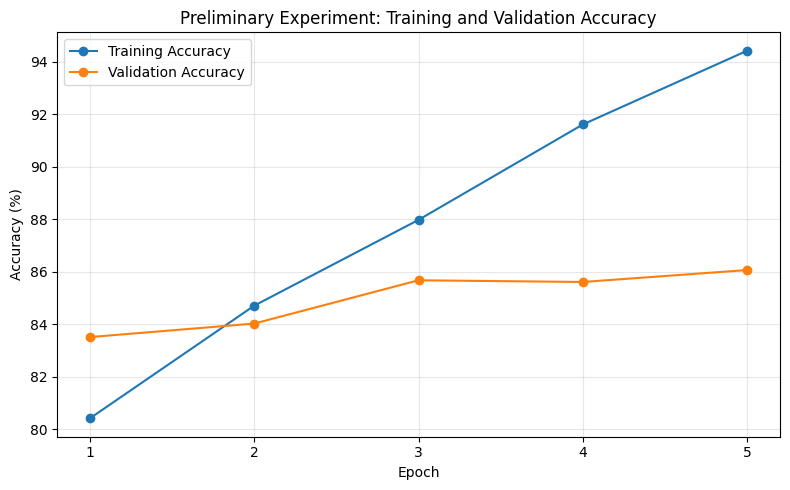

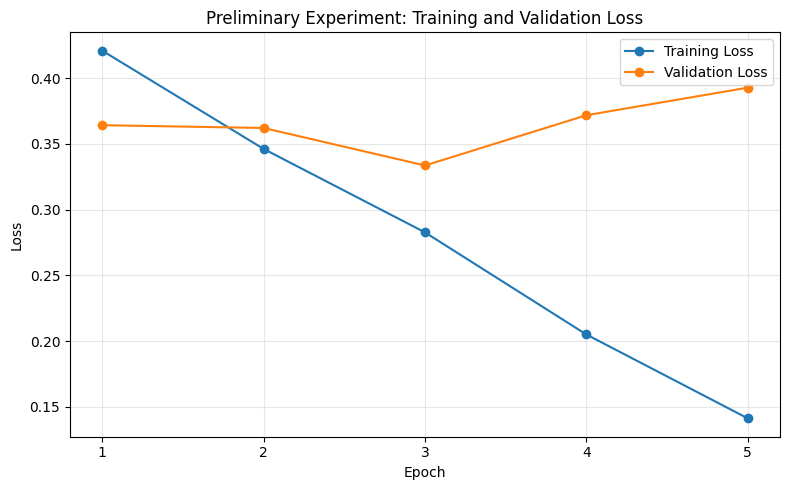

PRELIMINARY RESULTS SAVED
Best Epoch: 5
Best Validation Accuracy: 86.06%

CSV:      /content/drive/MyDrive/Research_Project/Results/dual_domain_preliminary_results.csv
Accuracy: /content/drive/MyDrive/Research_Project/Results/dual_domain_preliminary_accuracy.png
Loss:     /content/drive/MyDrive/Research_Project/Results/dual_domain_preliminary_loss.png


In [36]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# ============================================================
# SAVE PRELIMINARY EXPERIMENT RESULTS
# ============================================================

RESULTS_DIR = "/content/drive/MyDrive/Research_Project/Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Create results DataFrame
results_df = pd.DataFrame({
    "Epoch": range(1, len(history["train_loss"]) + 1),
    "Train Loss": history["train_loss"],
    "Train Accuracy": history["train_accuracy"],
    "Validation Loss": history["val_loss"],
    "Validation Accuracy": history["val_accuracy"]
})

# Save numerical results
csv_path = os.path.join(RESULTS_DIR, "dual_domain_preliminary_results.csv")
results_df.to_csv(csv_path, index=False)

# ============================================================
# 1. ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Epoch"],
    results_df["Train Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    results_df["Epoch"],
    results_df["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Preliminary Experiment: Training and Validation Accuracy")
plt.xticks(results_df["Epoch"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

accuracy_path = os.path.join(
    RESULTS_DIR,
    "dual_domain_preliminary_accuracy.png"
)

plt.savefig(accuracy_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 2. LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Epoch"],
    results_df["Train Loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    results_df["Epoch"],
    results_df["Validation Loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Preliminary Experiment: Training and Validation Loss")
plt.xticks(results_df["Epoch"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_path = os.path.join(
    RESULTS_DIR,
    "dual_domain_preliminary_loss.png"
)

plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# SUMMARY
# ============================================================

best_epoch = results_df.loc[
    results_df["Validation Accuracy"].idxmax(),
    "Epoch"
]

best_val_acc = results_df["Validation Accuracy"].max()

print("=" * 60)
print("PRELIMINARY RESULTS SAVED")
print("=" * 60)
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print()
print(f"CSV:      {csv_path}")
print(f"Accuracy: {accuracy_path}")
print(f"Loss:     {loss_path}")
print("=" * 60)

In [37]:
import os

checkpoint_path = "/content/drive/MyDrive/Research_Project/Checkpoints/dual_domain_preliminary_best.pth"

if os.path.exists(checkpoint_path):
    size_mb = os.path.getsize(checkpoint_path) / (1024 ** 2)
    print("✅ CHECKPOINT EXISTS")
    print(f"File: {checkpoint_path}")
    print(f"Size: {size_mb:.2f} MB")
else:
    print("❌ Checkpoint not found")

✅ CHECKPOINT EXISTS
File: /content/drive/MyDrive/Research_Project/Checkpoints/dual_domain_preliminary_best.pth
Size: 95.48 MB


In [38]:
import os

results_dir = "/content/drive/MyDrive/Research_Project/Results"

print("Files saved in Results folder:")
for file in os.listdir(results_dir):
    print("✅", file)

Files saved in Results folder:
✅ dual_domain_preliminary_results.csv
✅ dual_domain_preliminary_accuracy.png
✅ dual_domain_preliminary_loss.png
